# Proportions Plot — reproducing Julia `Single influx.ipynb` §Proportions Plot

Exact translation of the `li=1` run from the Julia notebook:
- `N = M = 20`, `B = 3`
- `Ks = 10 .^ range(0.5, 4.0, 10)` (10 values, ~3.2 → 10000)
- `m = c = cinflux = base10_lognormal(0.0, 0.001)` → `Dirac(1.0)`
- `pei = 1.0`, `linflux = 1.0`
- `pe = B/M = 0.15`, `l = 0.0`
- `num_byproducts = Binomial(M, B/M) = Binomial(20, 0.15)`
- `num_repeats = 10`
- `lsks = 10 .^ range(-6, 6, 10000)`

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scistats
from scipy.stats import binom as binom_dist

sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
sns.set_style("whitegrid", {"grid.color": '.9', 'grid.linestyle': '--',
                             'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})

import palettable as pal

colorTable = {}
colorTable['k'] = [0, 0, 0]
colorTable['g'] = [27/255, 158/255, 119/255]
colorTable['o'] = [217/255, 95/255, 2/255]

from ssmc.sampling import JansSampler3, Dirac
from ssmc.linstab import scan_k, classify
from ssmc.solver import solve_steady_state
from ssmc.plotting import STATE_COLORS

## Exact Julia parameters

In [3]:
N = 20          # number of strains
M = N           # number of resources
B = 3           # average byproducts per resource

# Julia: Ks = 10 .^ range(0.5, 4.0, 10)
Ks = np.logspace(0.5, 4.0, 10)

# Julia: lsks = 10 .^ range(-6, 6, 10000)
lsks = np.logspace(-6, 6, 10000)

n_per_K = 10    # num_repeats = 10
l_influx = 1.0

print("Ks:", np.round(Ks, 2))

Ks: [3.16000e+00 7.74000e+00 1.89600e+01 4.64200e+01 1.13650e+02 2.78260e+02
 6.81290e+02 1.66810e+03 4.08424e+03 1.00000e+04]


In [4]:
def base10_lognormal(b10m, b10std):
    """Port of Julia base10_lognormal: LogNormal(b10m*log(10), b10std*log(10))."""
    return scistats.lognorm(s=b10std * np.log(10), scale=np.exp(b10m * np.log(10)))


def make_sampler(K):
    """Exact port of the Julia do_df_run call with li=1 parameters."""
    return JansSampler3(
        Ns=N,
        Nr=M,
        m=base10_lognormal(0.0, 0.001),
        r=Dirac(1.0),
        num_influx_resources=1,
        K=Dirac(float(K)),
        prob_eating=B / M,                     # pe = 3/20 = 0.15
        prob_eating_influx=1.0,                # pei = 1.0
        num_byproducts=binom_dist(n=M, p=B/M), # Binomial(M, B/M)
        c=base10_lognormal(0.0, 0.001),
        l=Dirac(0.0),                          # l = 0.0
        cinflux=base10_lognormal(0.0, 0.001),
        linflux=Dirac(l_influx),               # linflux = 1.0
        Ds=Dirac(1e-12),
        Dr=Dirac(1.0),
        Drinflux=Dirac(1.0),
    )


def classify_one(sparams, ks=lsks, t_max=1e5):
    micrm = sparams.micrm
    Ns, Nr = micrm.Ns, micrm.Nr
    # Julia make_u0_onlyN: strains = g = 1.0, ALL resources = 0
    u0 = np.concatenate([np.ones(Ns), np.zeros(Nr)])
    u_ss, ok = solve_steady_state(micrm, u0, t_max=t_max, rtol=1e-9, atol=1e-11, ss_tol=1e-8)
    if not ok or np.max(u_ss[:Ns]) < 1e-6:
        return 'extinct'
    res = scan_k(sparams, u_ss, ks)
    return classify(res)

## Run simulations

In [5]:
from concurrent.futures import ProcessPoolExecutor
import os


def _run_one_K(args):
    """Worker: simulate n_per_K communities at one K value.
    Self-contained (imports its own deps + root path) so it pickles cleanly.
    """
    j, K, n_per_K, seed, root_path = args
    import sys
    if root_path not in sys.path:
        sys.path.insert(0, root_path)
    import numpy as np
    from scipy import stats as scistats
    from scipy.stats import binom as binom_dist
    from ssmc.sampling import JansSampler3, Dirac
    from ssmc.linstab import scan_k, classify
    from ssmc.solver import solve_steady_state

    lsks_local = np.logspace(-6, 6, 10000)
    N_l, M_l, B_l, l_inf_l = 20, 20, 3, 1.0

    def _b10ln(b10m, b10std):
        return scistats.lognorm(s=b10std * np.log(10), scale=np.exp(b10m * np.log(10)))

    sampler = JansSampler3(
        Ns=N_l, Nr=M_l,
        m=_b10ln(0.0, 0.001), r=Dirac(1.0),
        num_influx_resources=1, K=Dirac(float(K)),
        prob_eating=B_l / M_l, prob_eating_influx=1.0,
        num_byproducts=binom_dist(n=M_l, p=B_l / M_l),
        c=_b10ln(0.0, 0.001), l=Dirac(0.0),
        cinflux=_b10ln(0.0, 0.001), linflux=Dirac(l_inf_l),
        Ds=Dirac(1e-12), Dr=Dirac(1.0), Drinflux=Dirac(1.0),
    )

    rng = np.random.default_rng(seed)
    local_counts = {'extinct': 0, 'stable': 0, 'unstable': 0}
    not_ok = 0

    for _ in range(n_per_K):
        sparams = sampler(rng)
        micrm = sparams.micrm
        Ns_val, Nr_val = micrm.Ns, micrm.Nr
        # Julia make_u0_onlyN: strains = g = 1.0, ALL resources = 0
        u0 = np.concatenate([np.ones(Ns_val), np.zeros(Nr_val)])
        # Julia uses DynamicSS(TRBDF2()) with tol=1e-13, maxiters=1e6, timelimit=30s.
        # Approximate with a large t_max and tight ss_tol.
        u_ss, ok = solve_steady_state(micrm, u0,
                                      t_max=1e5, rtol=1e-9, atol=1e-11, ss_tol=1e-8)
        if not ok:
            not_ok += 1
        if not ok or np.max(u_ss[:Ns_val]) < 1e-6:
            label = 'extinct'
        else:
            label = classify(scan_k(sparams, u_ss, lsks_local))
        if label in local_counts:
            local_counts[label] += 1

    return j, K, local_counts, not_ok


_root_path = str(pathlib.Path.cwd().parent)

# Independent seeds per K, derived from a master seed via SeedSequence
_seed_seq = np.random.SeedSequence(42)
_k_seeds = [int(s.generate_state(1)[0]) for s in _seed_seq.spawn(len(Ks))]

n_workers = os.cpu_count()
print(f"Dispatching {len(Ks)} K-values × {n_per_K} repeats across {n_workers} workers …")

with ProcessPoolExecutor(max_workers=n_workers) as pool:
    futures = [pool.submit(_run_one_K, (j, float(K), n_per_K, _k_seeds[j], _root_path))
               for j, K in enumerate(Ks)]
    raw = [f.result() for f in futures]

counts = {s: np.zeros(len(Ks), dtype=int) for s in ('extinct', 'stable', 'unstable')}
not_ok_total = 0

for j, K, lc, nok in sorted(raw, key=lambda x: x[0]):
    for s in lc:
        counts[s][j] = lc[s]
    not_ok_total += nok
    print(f"K={K:8.2f}:  extinct={lc['extinct']:2d}  stable={lc['stable']:2d}  "
          f"unstable={lc['unstable']:2d}  not_ok={nok}")

print(f"\nnot_ok total: {not_ok_total} / {len(Ks) * n_per_K}")

Dispatching 10 K-values × 10 repeats across 12 workers …


K=    3.16:  extinct=10  stable= 0  unstable= 0  not_ok=0
K=    7.74:  extinct= 3  stable= 0  unstable= 7  not_ok=0
K=   18.96:  extinct= 1  stable= 0  unstable= 9  not_ok=0
K=   46.42:  extinct= 0  stable= 0  unstable=10  not_ok=0
K=  113.65:  extinct= 1  stable= 0  unstable= 9  not_ok=1
K=  278.26:  extinct= 0  stable= 0  unstable=10  not_ok=0
K=  681.29:  extinct= 0  stable= 0  unstable=10  not_ok=0
K= 1668.10:  extinct= 0  stable= 9  unstable= 1  not_ok=0
K= 4084.24:  extinct= 0  stable=10  unstable= 0  not_ok=0
K=10000.00:  extinct= 0  stable= 7  unstable= 3  not_ok=0

not_ok total: 1 / 100


## Proportions Plot

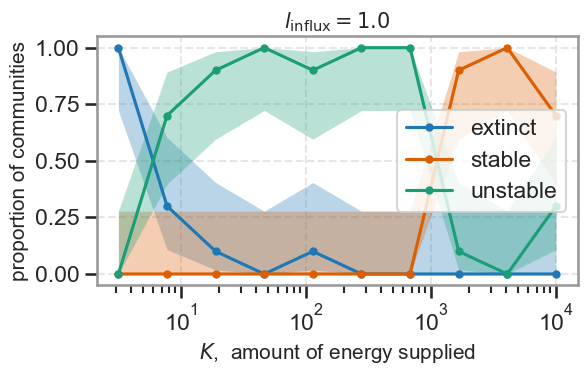

In [7]:
def wilson_ci(k, n, alpha=0.05):
    """Wilson score interval — matches Julia BinomialTest confint(:wilson)."""
    if n == 0:
        return (0.0, 0.0)
    z = scistats.norm.isf(alpha / 2)
    phat = k / n
    denom = 1 + z * z / n
    centre = (phat + z * z / (2 * n)) / denom
    half = (z / denom) * np.sqrt(phat * (1 - phat) / n + z * z / (4 * n * n))
    return (max(0.0, centre - half), min(1.0, centre + half))


fig, ax = plt.subplots(figsize=(6, 4))

for state in ('extinct', 'stable', 'unstable'):
    n_state = counts[state]
    p = n_state / n_per_K
    lo = np.empty(len(Ks))
    hi = np.empty(len(Ks))
    for j in range(len(Ks)):
        lo[j], hi[j] = wilson_ci(int(n_state[j]), n_per_K)
    ax.plot(Ks, p, marker='o', markersize=5, color=STATE_COLORS[state], label=state)
    ax.fill_between(Ks, lo, hi, color=STATE_COLORS[state], alpha=0.3, linewidth=0)

# Vertical line at K = 1/(1 - l_influx); undefined (infinite) for l_influx=1.0
if l_influx < 1.0:
    ax.axvline(1.0 / (1.0 - l_influx), color='k', linewidth=1.0)

ax.set_xscale('log')
ax.set_xlabel(r'$K$,  amount of energy supplied')
ax.set_ylabel('proportion of communities')
ax.set_title(rf'$l_{{\rm influx}} = {l_influx}$')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='center right')
plt.tight_layout()
plt.show()